## 1.4 Milvus Access Control RBAC
In the previous section, we learned abount the core architecture and components of the vector database Milvus. Now, we will learn one of Milvus's most critical capabilities: Access Control RBAC.

### Why is access control important when using Milvus?
When teams are small and their AI applications serve only a limited number of users, infrastructure is typically straightforward. A handful of engineers manage the systems; Milvus is used only for development or testing; operational workflows are simple and clear. At this early stage, access control rarely feels urgent—because the risk surface is small, and any mistakes are easily reversible.

As Milvus enters production, the number of users, services, and operators continues to grow, and usage patterns are rapidly evolving. Common scenarios include:
* Multiple business systems sharing a single Milvus instance
* Multiple teams accessing the same vector Collections
* Test, staging, and production data coexisting within a single cluster
* Different roles requiring varying levels of access, from read-only queries to write operations and operator control

Without clearly defined access boundaries, these configurations introduce foreseeable risks:
* Test workflows may accidentally delete production collections
* Developers may unintentionally modify indexes used by live services
* Widespread use of root accounts prevents tracking or auditing of operations
* Compromised applications may gain unrestricted access to all vector data

As usage increases, relying on informal agreements or shared administrator accounts becomes unsustainable. A consistent, enforceable access model becomes essential—and that's precisely what Milvus RBAC delivers.

### What is RBAC in Milvus?
[RBAC(Role-Based Access Control)](https://milvus.io/docs/zh/rbac.md) is an authorization model that controls access based on roles rather than individual users. In Milvus, RBAC enables you to precisely define which actions users or services are permitted to perform, and on which specific resources. It provides a structured, scalable approach to security management that remains effective as your system evolves from a single developer to a full production environment.

Milvus RBAC is built around the following core components:
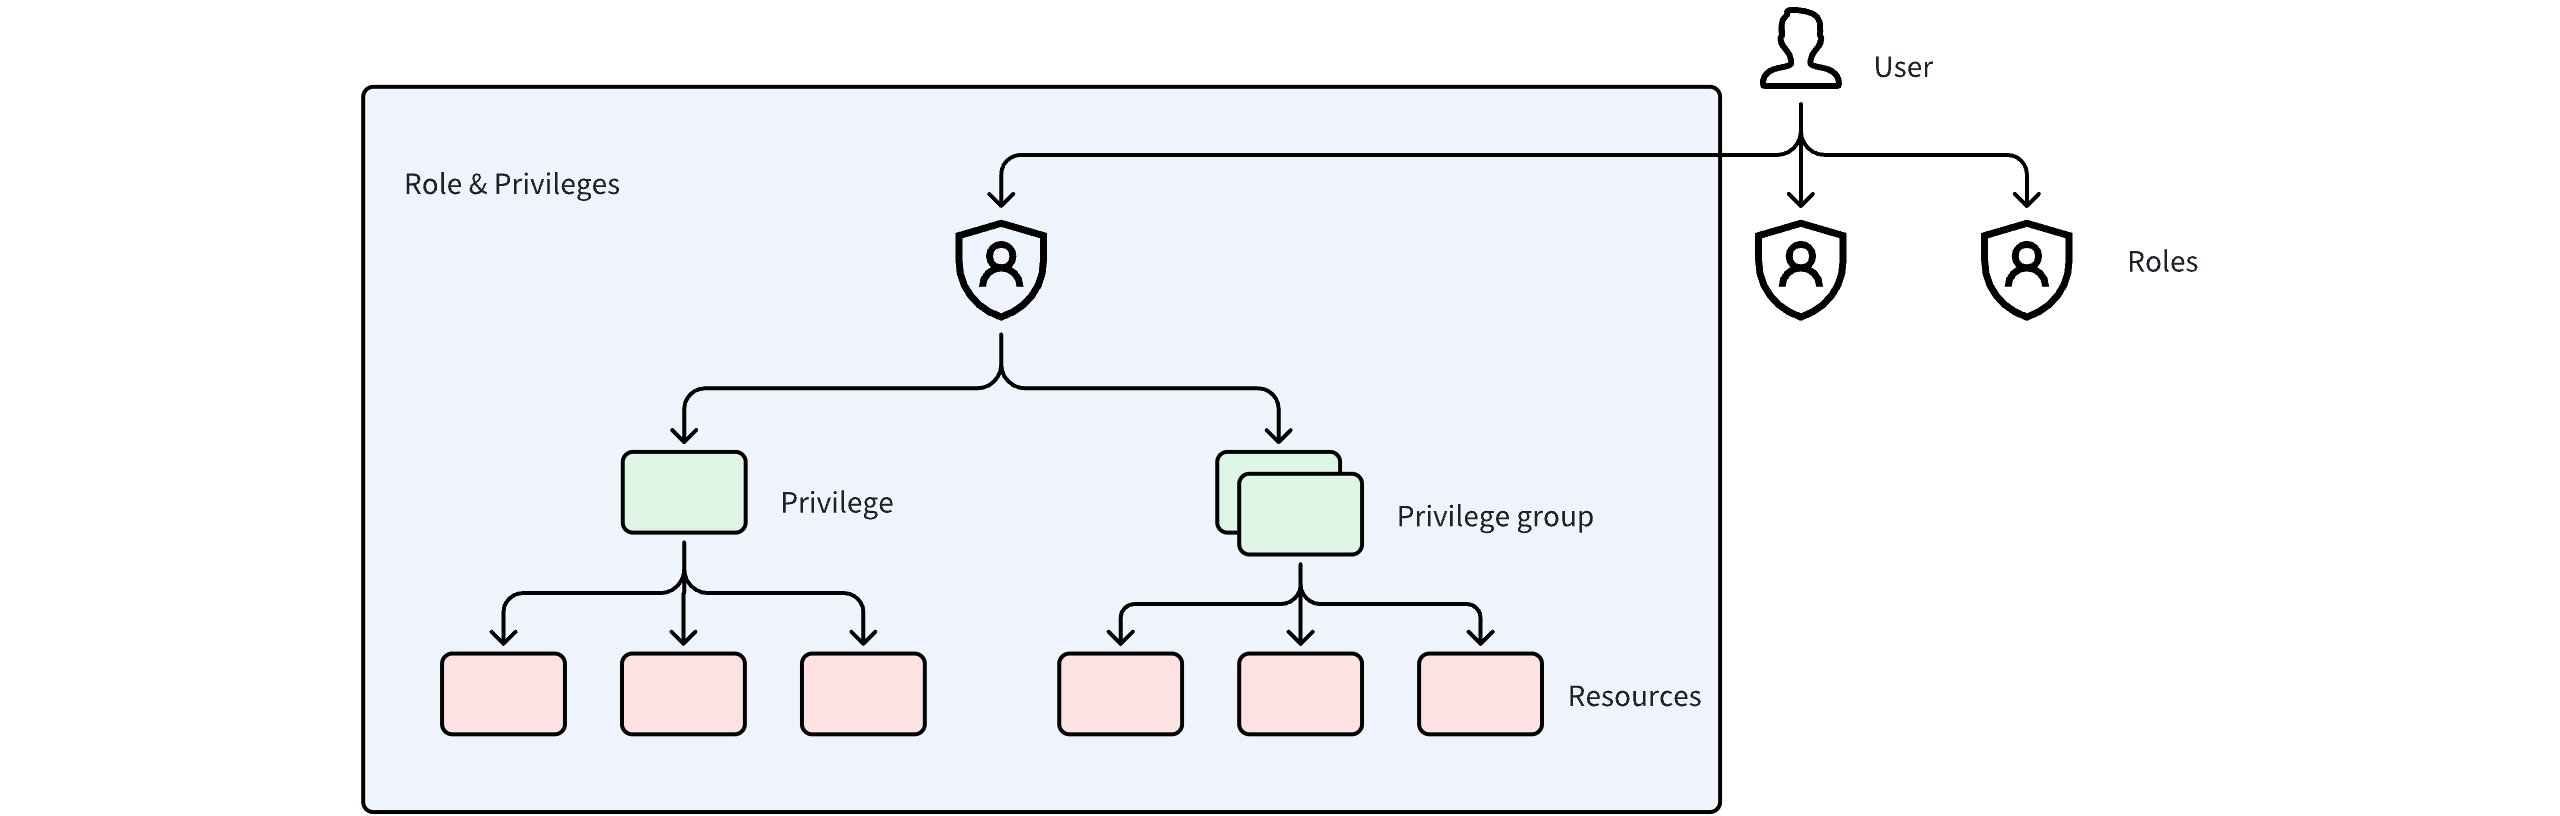

- **Resource**: Entities that can be accessed. In Milvus, resources include instance, database, and Collections.
- **Privilege**: Specific actions allowed on resources—such as creating Collections, inserting data, or deleting entities.
- **Privilege group**: A set of predefined related privileges, like "Read-Only" or "Write".
- **Role**: A combination of privileges and the resources they apply to. A role determine which actions can be performed and where they can be performed.
- **User**: An identity within Milvus. Each user has a unique ID and is granted a role or multiple roles.

These components form a clear hierarchy:
- **User is assigned roles**
- **Role defines privileges**
- **Privileges apply to specific resources**

A key design principle of Milvus is never assigning privileges directly to users. All access occurs through roles. This indirect approach simplifies management, reduces configuration errors, and makes privilege changes predictable.

In practical deployments, this model scales exceptionally well. When multiple users share a role, updating that role's privileges instantly updates all users' privileges without requiring individual modifications. This single point of control aligns with modern infrastructure access management practices.

### How RBAC works in Milvus?
#### 1.Prerequisites  
Before evaluating and enforcing RBAC rules, user authentication must be enabled so that each Milvus request can be associated with a specific user identity.

Below are two standard deployment methods.
- **Deploying with Docker Compose**   
If deploying Milvus using Docker Compose, edit the `milvus.yaml` configuration file and enable authorization by setting `common.security.authorizationEnabled` to `true`:

    ```yaml
    common:
    security:
        authorizationEnabled: true
    ```

- **Deploying with Helm Charts**  
If deploying Milvus using Helm Charts, edit the `values.yaml` file and add the following configuration to `extraConfigFiles.user.yaml`:

    ```yaml
    extraConfigFiles:
    user.yaml: |+
        common:
        security:
            authorizationEnabled: true
    ```

#### 2.Initialization
By default, Milvus creates a built-in `root` user upon system startup. The default password for this user is `Milvus`.

As an initial security step, connect to Milvus using the `root` user and immediately change the default password. It is strongly recommended to use a complex password to prevent unauthorized access.

In [ ]:
from pymilvus import MilvusClient
# Connect to Milvus using the default root user
client = MilvusClient(
    uri='http://localhost:19530', 
    token="root:Milvus"
)
# Update the root password
client.update_password(
    user_name="root",
    old_password="Milvus", 
    new_password="xgOoLudt3Kc#Pq68"
)

#### 3.Core Operations
##### 3.1 Create a user

For everyday use, it is recommended to create dedicated users instead of using the `root` account.

In [ ]:
client.create_user(user_name="user_1", password="P@ssw0rd")

##### 3.2 Create a role

Milvus provides a built-in `admin` role with full administrative privileges. However, for most production scenarios, it is recommended to create custom roles to achieve more granular access control.

In [ ]:
client.create_role(role_name="role_a")

##### 3.3 Create a privilege group

A privilege group is ombinations of multiple privileges. To simplify permission management, related privileges can be grouped and granted together.

Milvus includes the following built-in privilege groups:
* `COLL_RO`、`COLL_RW`、`COLL_ADMIN`
* `DB_RO`、`DB_RW`、`DB_ADMIN`
* `Cluster_RO`、`Cluster_RW`、`Cluster_ADMIN`

Using these built-in privilege groups can significantly reduce the complexity of permission design and enhance consistency across different roles.

You can either use the built-in privilege groups directly or create custom privilege groups as needed.

In [ ]:
# Create a privilege group
client.create_privilege_group(group_name='privilege_group_1')
# Add privileges to the privilege group
client.add_privileges_to_group(group_name='privilege_group_1', privileges=['Query', 'Search'])

##### 3.4 Grant a privilege or a privilege group to a role

After creating a role, you can grant a privilege or a privilege group to the role. The target resources for these privileges can be specified at different levels, including instance, database, or individual collection.

In [ ]:
client.grant_privilege_v2(
    role_name="role_a",
    privilege="Search",
    collection_name='collection_01',
    db_name='default',
)
client.grant_privilege_v2(
    role_name="role_a",
    privilege="privilege_group_1",
    collection_name='collection_01',
    db_name='default',
)
client.grant_privilege_v2(
    role_name="role_a",
    privilege="ClusterReadOnly",
    collection_name='*',
    db_name='*',
)

##### 3.5 Grant a role to a user
Once a role is assigned to a user, the user can access resources and perform the operations defined by those roles. Depending on the required scope of access, a user may be granted one or more roles.

In [ ]:
client.grant_role(user_name="user_1", role_name="role_a")

#### 4.Check and Revoke Access
**Check the roles assigned to the user**

In [ ]:
client.describe_user(user_name="user_1")

**Check the privileges assigned to the role**

In [ ]:
client.describe_role(role_name="role_a")

**Revoke privileges assigned to the role**

In [ ]:
client.revoke_privilege_v2(
    role_name="role_a",
    privilege="Search",
    collection_name='collection_01',
    db_name='default',
)
client.revoke_privilege_v2(
    role_name="role_a",
    privilege="privilege_group_1",
    collection_name='collection_01',
    db_name='default',
)

**Revoke user's role**

In [ ]:
client.revoke_role(
    user_name='user_1',
    role_name='role_a'
)

**Drop users and roles**

In [ ]:
client.drop_user(user_name="user_1")
client.drop_role(role_name="role_a")

### Example: Access Control Design for a Milvus-Driven RAG System
Consider a Retrieval-Augmented Generation (RAG) system built upon Milvus.

Within this system, distinct components and users possess clearly defined responsibilities, each requiring varying levels of access permissions.

| **Actor** | **Responsibility** | **Required Access Permissions** |
| --- | --- | --- |
| Platform Administrator | System operation and configuration | Instance-level management |
| Vector Ingestion Service | Vector data ingestion and updates | Read/write access |
| Search Service | Vector search and retrieval | Read-only access |

In [ ]:
from pymilvus import MilvusClient
client = MilvusClient(
    uri='http://localhost:19530',
    token="root:xxx"  # Replace with the updated root password
)
# 1. Create a user (use a strong password)
client.create_user(user_name="rag_admin", password="xxx")
client.create_user(user_name="rag_reader", password="xxx")
client.create_user(user_name="rag_writer", password="xxx")
# 2. Create roles
client.create_role(role_name="role_admin")
client.create_role(role_name="role_read_only")
client.create_role(role_name="role_read_write")
# 3. Grant privileges to the role
## Using built-in Milvus privilege groups
client.grant_privilege_v2(
    role_name="role_admin",
    privilege="Cluster_Admin",
    collection_name='*',
    db_name='*',
)
client.grant_privilege_v2(
    role_name="role_read_only",
    privilege="COLL_RO",
    collection_name='*',
    db_name='default',
)
client.grant_privilege_v2(
    role_name="role_read_write",
    privilege="COLL_RW",
    collection_name='*',
    db_name='default',
)
# 4. Assign the role to the user
client.grant_role(user_name="rag_admin", role_name="role_admin")
client.grant_role(user_name="rag_reader", role_name="role_read_only")
client.grant_role(user_name="rag_writer", role_name="role_read_write")

### Quick tips: How to operate access control securely in production
To ensure access control remains effective and manageable in long-running production systems, follow these practical guidelines.

1. **Change the default `root` password and restrict `root` account usage**  
Update the default `root` password immediately after initialization and limit its use to administrative tasks only. Avoid using or sharing the `root` account for routine operations. Instead, create dedicated users and roles for daily access to reduce risk and strengthen accountability.

2. **Physically isolate Milvus instances across environments**  
Deploy separate Milvus instances for development, staging, and production. Physical isolation provides stronger security boundaries than logical access controls alone, significantly reducing the risk of cross-environment errors.

3. **Adhere to the principle of least privilege**  
Grant only the permissions each role requires:  
- **Development Environment**: Permissions may be more permissive to support iteration and testing  
- **Production Environment**: Permissions should be strictly limited to what is necessary  
- **Regular Audits**: Periodically review existing permissions to ensure they remain necessary

4. **Proactively revoke permissions when no longer needed**  
Access control is not a one-time setup but requires ongoing maintenance. Promptly revoke roles and permissions when users, services, or responsibilities change. This prevents unused permissions from accumulating over time and becoming hidden security risks.

### Conclusion
Configuring access control in Milvus is not inherently complex, yet it is critical for operating the system securely and reliably in production. Through a carefully designed RBAC model, you can:

- Prevent accidental or destructive operations, **reducing risk**
- **Enhance security** by enforcing least-privilege access to vector data
- **Standardize operator practices** through clear separation of duties
- **Scale with confidence**, laying the foundation for multi-tenant and large-scale deployments

Access control is neither an optional feature nor a one-time task. It is a fundamental component of the long-term secure operation of Milvus.